# Fast Non-Stationary Iterated Tikhonov (FNSIT) — Image Reconstruction

## Inverse Problem

We observe a degraded image:

$$
y = A\,x + \varepsilon, \quad \varepsilon \sim \mathcal{N}(0, \sigma^2 I)
$$

where $A$ is the blur operator (convolution with a Gaussian PSF) and $\varepsilon$ is additive Gaussian noise.

## FNSIT Algorithm

FNSIT improves upon standard NSIT with a **double-correction** update at each iteration $n$:

**Step 1 — Compute residual:**
$$
r_n = y - A\,x_n
$$

**Step 2 — First correction (standard Tikhonov):**
$$
F_1 = (A^T A + \alpha_n I)^{-1}\, A^T r_n
$$

**Step 3 — Second correction (stabilising term):**
$$
F_2 = \alpha_n \,(A^T A + \alpha_n I)^{-1}\,(A^T A + \alpha_n^2 I)^{-1}\, A^T r_n
$$

**Step 4 — Weighted update:**
$$
x_{n+1} = x_n + 0.7\, F_1 + 0.3\, F_2
$$

**Regularization schedule (non-stationary):**
$$
\alpha_n = \alpha_0 \cdot q^n, \quad q \in (0,1)
$$

**Morozov discrepancy stopping:**
$$
\|A\,x_n - y\| \le \tau \cdot \delta, \quad \tau \approx 1.05
$$

## Error Metrics

$$
\text{MSE} = \frac{1}{N}\sum_{i=1}^{N}(x_i^{\text{rec}} - x_i^{\text{true}})^2, \qquad
\text{Relative Error} = \frac{\|x^{\text{rec}} - x^{\text{true}}\|}{\|x^{\text{true}}\|}
$$

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import convolve2d
import time

## 1. Load and Prepare Image

Convert to grayscale and normalise pixel values to $[0,1]$.

In [2]:
image_path = r"296059.jpg"

img = plt.imread(image_path)
if img.ndim == 3:
    img = img.mean(axis=2)

x_true = img.astype(float)
x_true /= x_true.max()

print("Image shape:", x_true.shape)

Image shape: (321, 481)


## 2. Forward Operator — Gaussian Blur + Noise

The blur kernel (Point Spread Function) is a 2D Gaussian:

$$
h(i,j) = \frac{1}{Z}\exp\!\Bigl(-\frac{i^2+j^2}{2\sigma_k^2}\Bigr), \qquad Z = \sum_{i,j} h(i,j)
$$

The forward model is:
$$
y = A\,x + \varepsilon = h * x + \varepsilon
$$

The adjoint operator $A^T$ is convolution with the flipped kernel $h(-i,-j)$.

In [3]:
def gaussian_kernel(size=9, sigma=2.0):
    ax = np.linspace(-(size // 2), size // 2, size)
    xx, yy = np.meshgrid(ax, ax)
    kernel = np.exp(-(xx**2 + yy**2) / (2 * sigma**2))
    kernel /= kernel.sum()
    return kernel


kernel = gaussian_kernel(size=9, sigma=2.0)

In [4]:
def A_op(x):
    return convolve2d(x, kernel, mode="same", boundary="symm")


def AT_op(x):
    flipped = np.flipud(np.fliplr(kernel))
    return convolve2d(x, flipped, mode="same", boundary="symm")

In [5]:
noise_std = 0.01
np.random.seed(42)
Ax = A_op(x_true)
eps = noise_std * np.random.randn(*Ax.shape)
y = Ax + eps

delta = np.linalg.norm(eps)
print(f"Noise level \u03b4 = {delta:.6f}")

Noise level δ = 3.929630


## 3. FNSIT Core — Double-Correction Inner Solver

The inner linear system $(A^T A + \alpha I)\,z = \text{rhs}$ is solved approximately
via gradient descent (no explicit matrix needed):

$$
z^{(j+1)} = z^{(j)} - \beta\bigl[(A^T A + \alpha I)\,z^{(j)} - \text{rhs}\bigr]
$$

In [6]:
def solve_inner(rhs, alpha, n_inner=25, step=0.18):
    """Approximate solve of (A^T A + alpha * I) z = rhs via gradient descent."""
    z = np.zeros_like(rhs)
    for _ in range(n_inner):
        grad = AT_op(A_op(z)) + alpha * z - rhs
        z -= step * grad
    return z


def fnsit_reconstruct_image(y, x_true, alpha0, q, max_iter,
                            n_inner=25, step=0.18, tau=1.05, delta=None):
    """
    FNSIT double-correction image reconstruction.

    F1 = (A^T A + alpha_n I)^{-1} A^T r
    F2 = alpha_n * (A^T A + alpha_n I)^{-1} (A^T A + alpha_n^2 I)^{-1} A^T r
    x  = x + 0.7 * F1 + 0.3 * F2
    """
    x = np.zeros_like(y)
    residuals = []
    errors = []

    for k in range(max_iter):
        alpha_n = alpha0 * (q ** k)
        r = y - A_op(x)
        At_r = AT_op(r)

        # First correction
        F1 = solve_inner(At_r, alpha_n, n_inner, step)

        # Second correction
        temp = solve_inner(At_r, alpha_n**2, n_inner, step)
        F2 = alpha_n * solve_inner(temp, alpha_n, n_inner, step)

        # Stable weighted update
        x = x + 0.7 * F1 + 0.3 * F2

        res_norm = np.linalg.norm(A_op(x) - y)
        residuals.append(res_norm)

        err = np.linalg.norm(x - x_true) / np.linalg.norm(x_true)
        errors.append(err)

        # Morozov discrepancy stopping
        if delta is not None and res_norm <= tau * delta:
            print(f"  Morozov stopping at iteration {k}")
            break

    return x, residuals, errors

## 4. FNSIT Reconstruction

In [7]:
alpha0 = 0.1
q = 0.9
max_iter = 40

print("Running FNSIT reconstruction...")
t0 = time.time()
x_fnsit, residuals, errors = fnsit_reconstruct_image(
    y, x_true, alpha0, q, max_iter, n_inner=25, step=0.18, tau=1.05, delta=delta
)
t_elapsed = time.time() - t0

mse_fnsit = np.mean((x_fnsit - x_true) ** 2)
rel_error_fnsit = np.linalg.norm(x_fnsit - x_true) / np.linalg.norm(x_true)

print(f"\nFNSIT Results (time: {t_elapsed:.1f}s):")
print(f"  Relative Error: {rel_error_fnsit:.6f}")
print(f"  MSE:            {mse_fnsit:.8f}")
print(f"  Iterations:     {len(errors)}")

Running FNSIT reconstruction...
  Morozov stopping at iteration 4

FNSIT Results (time: 24.7s):
  Relative Error: 0.087175
  MSE:            0.00132258
  Iterations:     5


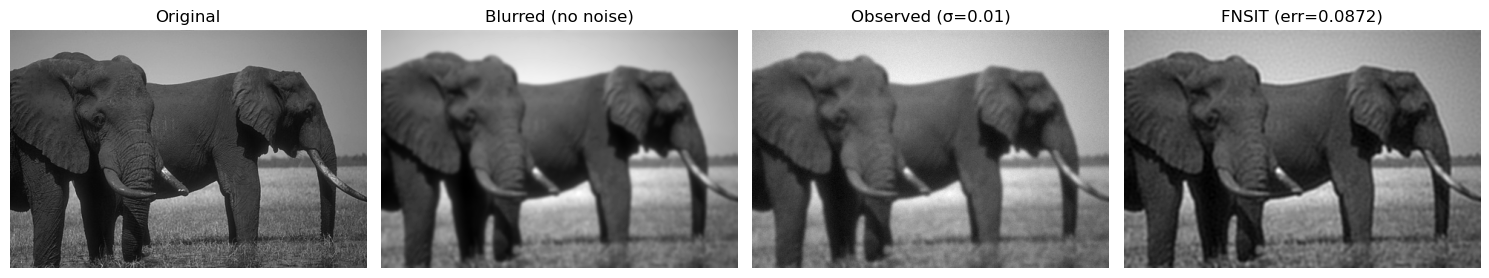

In [8]:
plt.figure(figsize=(15, 4))

plt.subplot(1, 4, 1)
plt.imshow(x_true, cmap="gray")
plt.title("Original")
plt.axis("off")

plt.subplot(1, 4, 2)
plt.imshow(Ax, cmap="gray")
plt.title("Blurred (no noise)")
plt.axis("off")

plt.subplot(1, 4, 3)
plt.imshow(y, cmap="gray")
plt.title(f"Observed (\u03c3={noise_std})")
plt.axis("off")

plt.subplot(1, 4, 4)
plt.imshow(x_fnsit, cmap="gray")
plt.title(f"FNSIT (err={rel_error_fnsit:.4f})")
plt.axis("off")

plt.tight_layout()
plt.show()

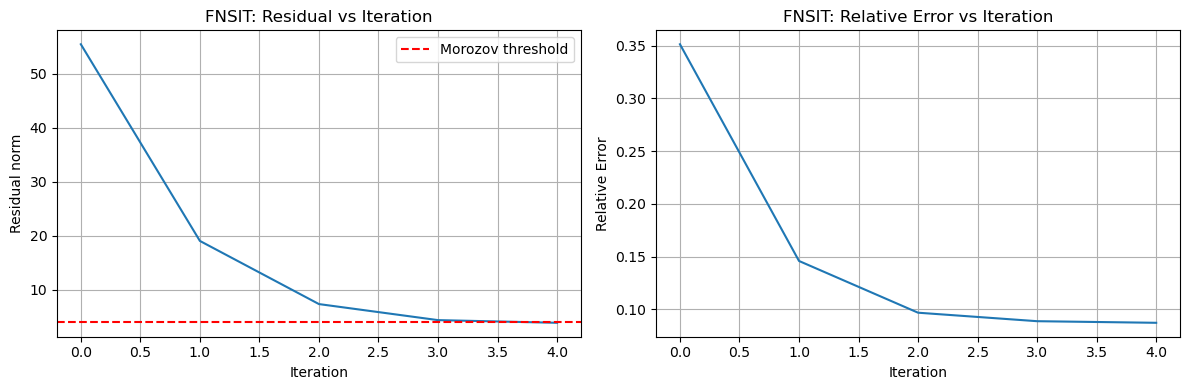

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(residuals)
axes[0].axhline(1.05 * delta, color="r", linestyle="--", label="Morozov threshold")
axes[0].set_xlabel("Iteration")
axes[0].set_ylabel("Residual norm")
axes[0].set_title("FNSIT: Residual vs Iteration")
axes[0].legend()
axes[0].grid(True)

axes[1].plot(errors)
axes[1].set_xlabel("Iteration")
axes[1].set_ylabel("Relative Error")
axes[1].set_title("FNSIT: Relative Error vs Iteration")
axes[1].grid(True)

plt.tight_layout()
plt.show()

## 5. Error Difference Map

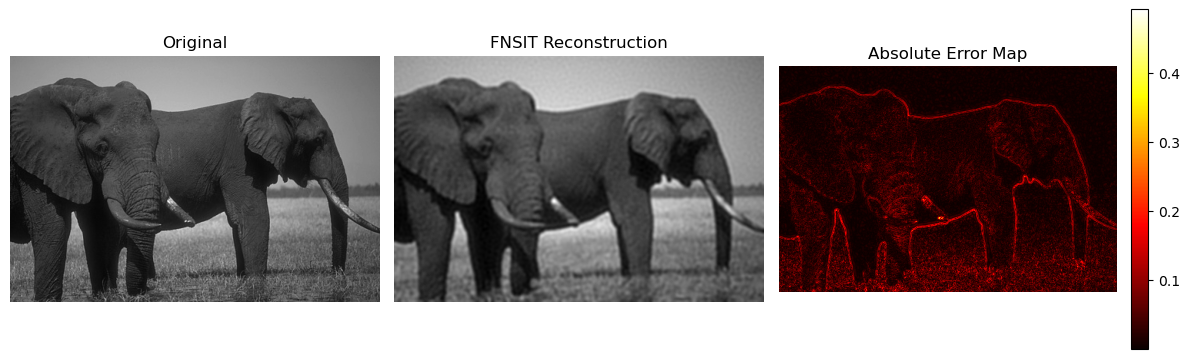

In [10]:
diff = np.abs(x_fnsit - x_true)

plt.figure(figsize=(12, 4))

plt.subplot(1, 3, 1)
plt.imshow(x_true, cmap="gray")
plt.title("Original")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(x_fnsit, cmap="gray")
plt.title("FNSIT Reconstruction")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(diff, cmap="hot")
plt.colorbar(fraction=0.046, pad=0.04)
plt.title("Absolute Error Map")
plt.axis("off")

plt.tight_layout()
plt.show()

## 6. Final Summary

In [11]:
print("=" * 55)
print("FNSIT IMAGE RECONSTRUCTION — FINAL SUMMARY")
print("=" * 55)
print(f"\nParameters:")
print(f"  alpha0 = {alpha0},  q = {q},  max_iter = {max_iter}")
print(f"  n_inner = 25,  step = 0.18,  tau = 1.05")
print(f"\nResults:")
print(f"  MSE            = {mse_fnsit:.8f}")
print(f"  Relative Error = {rel_error_fnsit:.6f}")
print(f"  Iterations     = {len(errors)}")
print(f"\nSetup:")
print(f"  Image size:  {x_true.shape[0]}x{x_true.shape[1]}")
print(f"  Kernel:      9x9 Gaussian (\u03c3=2.0)")
print(f"  Noise std:   {noise_std}")
print(f"  Noise \u03b4:     {delta:.6f}")

FNSIT IMAGE RECONSTRUCTION — FINAL SUMMARY

Parameters:
  alpha0 = 0.1,  q = 0.9,  max_iter = 40
  n_inner = 25,  step = 0.18,  tau = 1.05

Results:
  MSE            = 0.00132258
  Relative Error = 0.087175
  Iterations     = 5

Setup:
  Image size:  321x481
  Kernel:      9x9 Gaussian (σ=2.0)
  Noise std:   0.01
  Noise δ:     3.929630
